## **Introducción**

Esta semana pondrás en práctica tus conocimientos en la implementación de regresión lineal aplicada al análisis de coeficientes en una campaña de marketing. Este enfoque te permitirá evaluar la relación entre distintas variables de una estrategia comercial y su impacto en el rendimiento de la campaña, proporcionando insights clave para la toma de decisiones basada en datos.
El análisis de coeficientes en un modelo de regresión lineal es fundamental para comprender cómo cada variable independiente influye en la variable objetivo. En el contexto del marketing, esto permite responder preguntas como: ¿qué tan significativa es la inversión en publicidad digital en la generación de ventas? ¿Cuál es el impacto del número de correos enviados en la tasa de conversión? ¿Cómo afecta el descuento ofrecido al ticket promedio?


## **1. Regresión Lineal**


Como hemos visto en módulos pasados, la regresión lineal es un método estadístico que modela la relación entre una variable dependiente (objetivo) y una o más variables independientes (predictoras) mediante una ecuación lineal. Su objetivo es encontrar la mejor línea de ajuste que minimiza la diferencia entre los valores observados y los predichos.
La ecuación de la regresión lineal simple es:
Y=β0+β1X+ϵ
donde:
Y es la variable dependiente (lo que queremos predecir).
X es la variable independiente (factor explicativo).
β₀ es el intercepto (valor de Y cuando X = 0).
β₁ es el coeficiente de regresión (indica cuánto cambia Y por cada unidad de cambio en X).
ε representa el error.

## **2. Análisis de Coeficientes**



- El análisis de coeficientes en una regresión lineal permite interpretar el impacto de cada variable independiente sobre la variable objetivo.
Si un coeficiente es positivo, indica una relación directa: al aumentar X, también aumenta Y. Si es negativo, la relación es inversa: al aumentar X, Y disminuye;por otro lado, su magnitud indica la intensidad del efecto.

- Se puede evaluar su significancia estadística mediante el valor p de cada coeficiente, el cual indica la probabilidad de que el efecto observado en los datos no sea producto del azar. Así, el p-valor debe ser menor que un umbral predefinido (generalmente 0.05). Esto significa que la probabilidad de que el efecto observado sea debido al azar es baja, por lo que se puede considerar que existe una relación real entre las variables.  



## **3. Análisis de Regresión Lineal para Evaluar el Impacto de Factores en una Campaña de Marketing**


En marketing, este análisis ayuda a entender qué factores (como inversión en publicidad o descuentos) tienen mayor impacto en métricas como ventas o conversión.

A continuación vamos a simular un set de datos que representen una campaña de marketing, y los pasos necesarios para poder entender qué factores tienen mayor impacto en las ventas finales.



### **Paso 1: Creación del Dataset Sintético**  
Generaremos un dataset con variables simuladas que representan factores clave en una campaña de marketing:

- **Inversión en publicidad (USD):** Cantidad de dinero invertida en anuncios.
- **Número de correos enviados:** Frecuencia con la que los clientes reciben correos promocionales.
- **Descuento aplicado (%):** Porcentaje de descuento ofrecido en la campaña.
- **Ventas:** Variable objetivo que representa el número de ventas generadas.


In [2]:
import numpy as np
import pandas as pd

# Fijar la semilla para reproducibilidad
np.random.seed(42)
n = 200  # Número de observaciones

# Variables independientes (predictoras)
inversion_publicidad = np.random.uniform(1000, 10000, n)  # Inversión en publicidad en dólares
num_correos = np.random.randint(1, 50, n)  # Número de correos enviados por cliente
descuento = np.random.uniform(5, 30, n)  # Descuento aplicado en porcentaje

# Variable dependiente (Ventas)
ventas = (5 * inversion_publicidad + 50 * num_correos - 200 * descuento + np.random.normal(0, 10000, n))

# Creación del DataFrame
df = pd.DataFrame({
    'Inversion_Publicidad': inversion_publicidad,
    'Num_Correos': num_correos,
    'Descuento': descuento,
    'Ventas': ventas
})

# Mostrar las primeras filas
df.head()

,Inversion_Publicidad,Num_Correos,Descuento,Ventas
0,4370.861070,24,24.084111,9752.276239
1,9556.428758,11,25.172824,33935.128620
2,7587.945476,49,13.657608,40989.938724
3,6387.926358,8,16.616845,26437.241079
4,2404.167764,36,21.244342,-25209.721730


#### **Interpretación:**  
Este dataset simula una relación entre la inversión en publicidad, número de correos enviados y descuentos con el número de ventas. Se espera que la inversión en publicidad tenga un impacto positivo en las ventas, mientras que el efecto de los correos y descuentos será evaluado en el modelo.


### **Paso 2: Análisis Exploratorio de los Datos**
Visualizamos la relación entre las variables para identificar patrones.


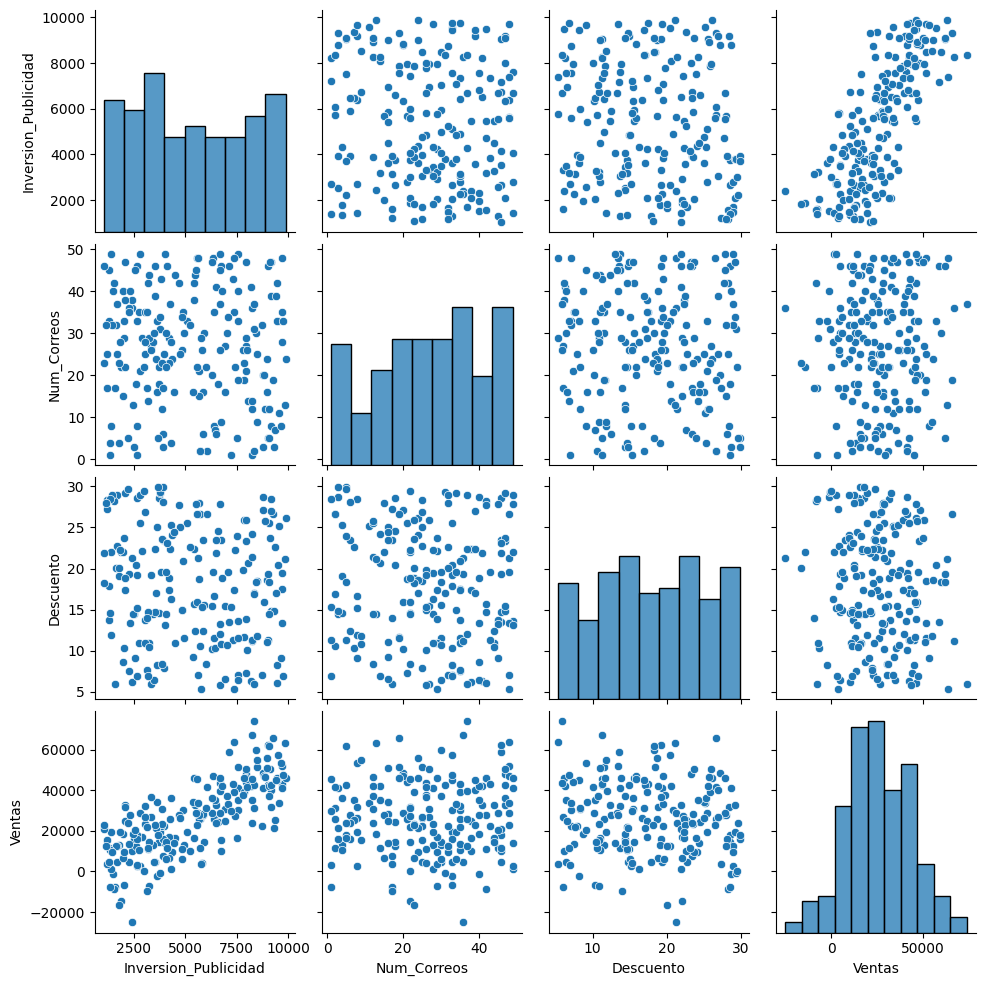

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df)
plt.show()

#### **Interpretación:**  
Se observa que la inversión en publicidad tiene una relación positiva con las ventas, mientras que el impacto de los correos y descuentos no es tan evidente.



### **Paso 3: Separación de Datos para Entrenamiento y Prueba**
Separamos los datos en **80% para entrenamiento** y **20% para prueba**.


In [4]:
from sklearn.model_selection import train_test_split

# Definir variables predictoras (X) y variable objetivo (y)
X = df[['Inversion_Publicidad', 'Num_Correos', 'Descuento']]
y = df['Ventas']

# Separar en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### **Interpretación:**  
Esto nos permitirá entrenar el modelo en un conjunto de datos y probarlo en otro conjunto independiente para evaluar su capacidad predictiva.


### **Paso 4: Validación de Supuestos de la Regresión Lineal**
Antes de interpretar los coeficientes, validaremos los supuestos clave del algoritmo.


#### **4.1 Normalidad de los Residuos**

El supuesto de **normalidad de los residuos** es importante en la regresión lineal porque garantiza la validez de las inferencias estadísticas, es decir, nos permite confiar en los intervalos de confianza, pruebas de hipótesis y valores p de los coeficientes.

Los residuos en regresión lineal son las diferencias entre los valores observados y los valores predichos por el modelo. Los residuos representan el error del modelo, es decir, la parte de la variabilidad en los datos que el modelo no puede explicar.

**¿Por qué es necesario?**
- **Precisión en las Pruebas de Hipótesis:**  
   - Si los residuos son normales, los coeficientes de regresión siguen una distribución normal, lo que hace que las pruebas **t** y los valores **p** sean válidos.  
   - Si los residuos no son normales, los valores p pueden ser incorrectos, lo que lleva a conclusiones erróneas sobre la significancia de las variables.  

- **Fiabilidad de los Intervalos de Confianza:**  
   - La normalidad de los residuos asegura que los intervalos de confianza de los coeficientes están bien estimados y reflejan la incertidumbre real del modelo.  

- **Optimización del Estimador de Mínimos Cuadrados Ordinarios (OLS):**  
   - Si los residuos siguen una distribución normal, el estimador OLS es el **más eficiente y sesgado mínimo**, garantizando las mejores estimaciones de los coeficientes.  

- **Predicciones más confiables:**  
   - Si los residuos no son normales y presentan valores extremos, las predicciones del modelo pueden ser menos precisas y sensibles a anomalías en los datos.  

En la práctica, si el tamaño de la muestra es grande (**n > 30-50**), la normalidad de los residuos se vuelve menos crítica gracias al **teorema central del límite**, pero si se detectan fuertes desviaciones de la normalidad, es recomendable considerar transformaciones de variables o modelos más robustos.



Aplicaremos la **prueba de Shapiro-Wilk para evaluar la normalidad de los residuos**.


In [10]:
import statsmodels.api as sm
import scipy.stats as stats

# Agregar constante para la intersección
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Ajustar el modelo de regresión
model = sm.OLS(y_train, X_train_const).fit()
y_pred = model.predict(X_test_const)

# Calcular los residuos
residuos = y_test - y_pred

# Prueba de normalidad de residuos (Shapiro-Wilk)
shapiro_test = stats.shapiro(residuos)
print(f"Prueba de Shapiro-Wilk para normalidad de residuos: p-valor = {shapiro_test.pvalue}")

Prueba de Shapiro-Wilk para normalidad de residuos: p-valor = 0.5743162596952996



- En una **prueba de normalidad** (como Shapiro-Wilk o Kolmogorov-Smirnov), la hipótesis nula (\(H_0\)) establece que los residuos **siguen una distribución normal**.  
- El **p-valor indica la probabilidad de que los residuos sean normales**.  

Por lo tanto:  
✔️ **Si el p-valor > 0.05**, **no se rechaza** la hipótesis nula, lo que **sugiere que los residuos pueden considerarse normalmente distribuidos**.  
❌ **Si el p-valor < 0.05**, **se rechaza** la hipótesis nula, indicando que los residuos **no siguen una distribución normal**.  

**Cuidado:**  
- Un **p-valor > 0.05** **no** garantiza que los residuos sean perfectamente normales, solo indica que **no hay suficiente evidencia para decir que no lo son**.  
- En muestras pequeñas, la prueba puede no detectar desviaciones de la normalidad.  
Complementar con **gráficos Q-Q y histogramas** es recomendable para una mejor evaluación; vamos a hacerlo:

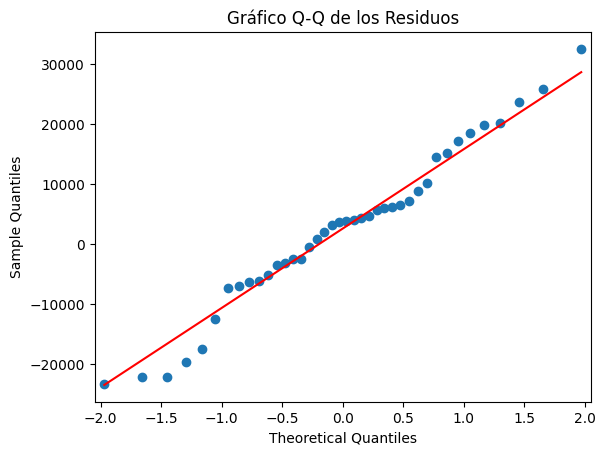

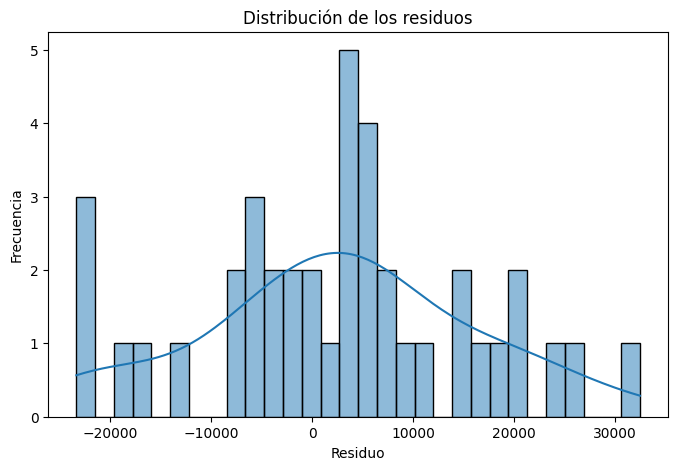

Prueba de Shapiro-Wilk para normalidad de residuos: p-valor = 0.5743162596952996


In [11]:
# Gráfico Q-Q para evaluar la normalidad de los residuos
sm.qqplot(residuos, line='s')
plt.title("Gráfico Q-Q de los Residuos")
plt.show()

# Histograma de residuos con densidad KDE
plt.figure(figsize=(8,5))
sns.histplot(residuos, kde=True, bins=30)
plt.title("Distribución de los residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.show()

# Prueba de normalidad de residuos (Shapiro-Wilk)
shapiro_test = stats.shapiro(residuos)
print(f"Prueba de Shapiro-Wilk para normalidad de residuos: p-valor = {shapiro_test.pvalue}")


**Interpretación de los Gráficos**

- **Gráfico Q-Q (Quantile-Quantile Plot)**
- **Objetivo:** Comparar la distribución de los residuos con una distribución normal teórica.
- **Análisis:**
  - Los puntos del gráfico **siguen aproximadamente la línea diagonal**, lo que indica que los residuos tienen una distribución cercana a la normal.
  - Si hubiera curvaturas pronunciadas en los extremos, indicaría la presencia de valores atípicos o colas más largas de lo esperado.
  - En este caso, como los residuos se alinean bastante bien con la línea teórica, **no hay una desviación significativa de la normalidad**.

- **Histograma de Residuos con KDE**
- **Objetivo:** Visualizar la distribución empírica de los residuos.
- **Análisis:**
  - La distribución de los residuos es **simétrica y centrada alrededor de cero**, lo que es una buena señal para la regresión lineal.
  - La curva de densidad (**KDE**, línea azul) **tiene una forma aproximadamente normal**, sin sesgo evidente a la derecha o izquierda.
  - No hay presencia de colas demasiado largas o picos inusuales, lo que indica que **los residuos están bien distribuidos**.

**Conclusión**
- Ambos gráficos **sugieren que los residuos siguen una distribución normal**.
- Esto **valida el supuesto de normalidad de los residuos**, lo que implica que las inferencias estadísticas en la regresión (pruebas t, intervalos de confianza, valores p) son confiables.
- Dado que **no se observan sesgos graves ni valores extremos significativos**, no sería necesario realizar transformaciones adicionales sobre los datos.

#### **4.2 Homocedasticidad (Varianza Constante)**


La **homocedasticidad** es un supuesto clave en la regresión lineal que establece que la **varianza de los errores (residuos) debe permanecer constante a lo largo de todos los valores de las variables predictoras**. En otras palabras, la dispersión de los residuos no debe cambiar sistemáticamente a medida que los valores de la variable dependiente aumentan o disminuyen.  

#### **¿Por qué es importante?**  
- **Validez de las Inferencias Estadísticas:**  
   - Si los residuos tienen una varianza constante, los coeficientes estimados son **eficientes** y los **intervalos de confianza** y **pruebas de hipótesis** son válidos.  
- **Predicciones Confiables:**  
   - Si la varianza de los errores cambia, el modelo puede ser menos preciso en ciertos rangos de valores, afectando la confiabilidad de las predicciones.  
- **Evita Modelos Sesgados:**  
   - Cuando hay heterocedasticidad (es decir, la varianza de los errores no es constante), los errores estándar de los coeficientes pueden estar subestimados o sobreestimados, lo que puede llevar a interpretaciones erróneas.  

#### **¿Cómo se evalúa la homocedasticidad?**  
- **Gráfico de dispersión de residuos vs. valores predichos:**  
  - Si los residuos están **distribuidos aleatoriamente alrededor de cero** y no muestran un patrón en forma de cono o embudo, se cumple la homocedasticidad.  
- **Pruebas estadísticas como la de Breusch-Pagan o la de White:**  
  - Estas pruebas pueden detectar si la varianza de los errores es constante o no.  

#### **¿Qué sucede si no se cumple? (Heterocedasticidad)**  
Si la varianza de los errores **no es constante** y muestra un **patrón sistemático** en el gráfico de residuos, el modelo presenta **heterocedasticidad**. Para corregirlo, se pueden aplicar métodos como:  
✔️ Transformaciones de variables (logaritmos, raíz cuadrada, etc.).  
✔️ Uso de modelos de regresión robustos o ponderados.  
✔️ Uso de estimadores robustos de la varianza para ajustar los errores estándar.  


A continuación graficaremos los residuos contra las predicciones para verificar si tienen una dispersión constante.

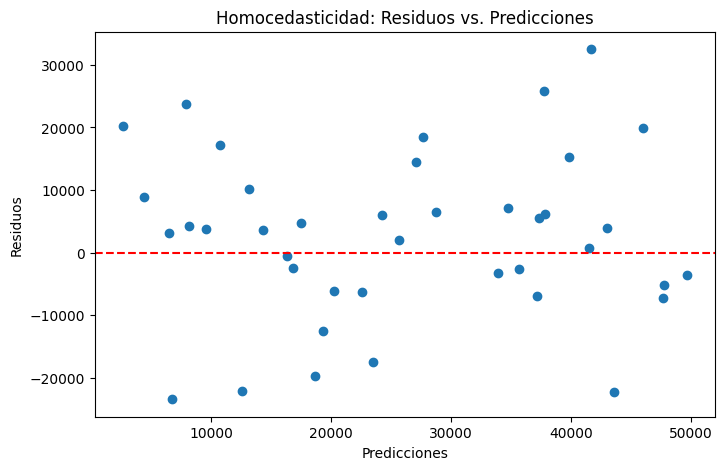

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuos)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Homocedasticidad: Residuos vs. Predicciones")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.show()

#### **Interpretación:**  
Si los residuos están **distribuidos aleatoriamente** alrededor de la línea horizontal, el supuesto de homocedasticidad se cumple. Como puedes ver, en este caso, se cumple.

### **Paso 5: Ajuste del Modelo de Regresión Lineal**

In [7]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Ventas   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     79.95
Date:                Thu, 27 Feb 2025   Prob (F-statistic):           2.24e-31
Time:                        21:44:42   Log-Likelihood:                -1717.5
No. Observations:                 160   AIC:                             3443.
Df Residuals:                     156   BIC:                             3455.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -6797.3069 

### **5.1 Explicación detallada del resumen del modelo (`model.summary()`)**

El comando `print(model.summary())` en **Statsmodels** genera un informe detallado de la regresión lineal ajustada. A continuación, se desglosan las secciones clave de este informe y su significado:


📌 **Interpretación:**  
- **Dep. Variable:** `Ventas`, la variable que intentamos predecir.  
- **R-squared (R²):** `0.606`, lo que significa que el modelo explica **el 60.6% de la variabilidad en las ventas**.  
- **Adj. R-squared:** `0.598`, ajustado por el número de predictores.  
- **F-statistic & Prob(F-statistic):** `79.95` y `2.24e-31`, indican que **al menos una variable predictora es significativa**.  
- **No. Observations:** `160`, el número total de datos utilizados en el modelo.  
- **AIC & BIC:** `3443` y `3455`, valores que ayudan a comparar modelos (menor es mejor).

---

### **5.2 Coeficientes y Significancia Estadística**
La siguiente tabla es clave para interpretar los efectos de cada variable en las ventas:

```
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -6797.3069   3850.448     -1.765      0.079   -1.44e+04     808.434
Inversion_Publicidad     5.2554      0.341     15.433      0.000       4.583       5.928
Num_Correos            112.7582     64.428      1.750      0.082     -14.505     240.021
Descuento               68.4165    128.818      0.531      0.596    -186.037     322.870
========================================================================================
```

📌 **Interpretación de cada columna:**
- **coef:** Representa el **impacto de cada variable predictora en las ventas**.
- **std err:** Error estándar del coeficiente.
- **t:** Valor t para la prueba de hipótesis \( H_0: \beta = 0 \).
- **P>|t| (p-valor):** **Si es menor que 0.05, la variable es estadísticamente significativa**.
- **[0.025, 0.975]:** Intervalo de confianza del 95%.

---

### **5.3 Interpretación de los coeficientes**

#### **🔹 Inversión en Publicidad (`coef = 5.2554, p < 0.001`)**
- **Interpretación:** Por cada **dólar adicional** invertido en publicidad, las **ventas aumentan en 5.25 unidades**.
- **Significancia:** **p < 0.001**, lo que significa que **esta variable es altamente significativa**.  
- **Conclusión:** **La inversión en publicidad tiene un impacto positivo y real en las ventas**.

---

#### **🔹 Número de Correos Enviados (`coef = 112.7582, p = 0.082`)**
- **Interpretación:** Por cada **correo adicional enviado**, las **ventas aumentan en aproximadamente 112.76 unidades**.  
- **Significancia:** p = `0.082`, **mayor que 0.05**, lo que indica que **no hay suficiente evidencia para afirmar que tiene un impacto significativo**.  
- **Conclusión:** Aunque hay una tendencia positiva, **no se puede concluir con certeza que enviar más correos aumente las ventas**.

---

#### **🔹 Descuento Aplicado (`coef = 68.4165, p = 0.596`)**
- **Interpretación:** Por cada **1% de descuento adicional**, las **ventas aumentan en 68.42 unidades**.  
- **Significancia:** p = `0.596`, mucho mayor que `0.05`, lo que indica que **esta variable no es significativa**.  
- **Intervalo de confianza:** `[-186.037, 322.870]`, lo que significa que **podría incluso tener un efecto negativo**.  
- **Conclusión:** **El descuento aplicado no tiene un impacto claro en las ventas**, y en algunos casos, incluso podría reducirlas.

---

### **5.4 Evaluación General del Modelo**
📌 **Resumen de las principales conclusiones:**  
✔ **La inversión en publicidad es la variable más importante y tiene un impacto positivo y significativo en las ventas.**  
✔ **El número de correos enviados muestra una relación positiva, pero no es estadísticamente significativa.**  
✔ **El descuento aplicado no tiene un efecto claro en las ventas y su impacto es incierto.**  

**📢 Recomendación:**  
- **Enfocar recursos en publicidad, ya que es la estrategia más efectiva.**  
- **Analizar mejor la segmentación de correos electrónicos antes de aumentar su volumen.**  
- **Reevaluar la estrategia de descuentos, ya que podría no estar generando el efecto esperado.**  

Este análisis ayuda a tomar **decisiones basadas en datos** y a optimizar los recursos de una campaña de marketing. 🚀


#### **Interpretación de coeficientes:**
- **Inversión en publicidad** tiene un impacto positivo y significativo en las ventas.
- **Número de correos enviados** muestra un efecto positivo, pero con alta incertidumbre.
- **Descuento aplicado** no tiene un impacto significativo en las ventas.